In [157]:
import pandas as pd
import numpy as np

In [158]:
df=pd.read_csv("housing.csv")

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [160]:
df["median_income"]

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: median_income, Length: 20640, dtype: float64

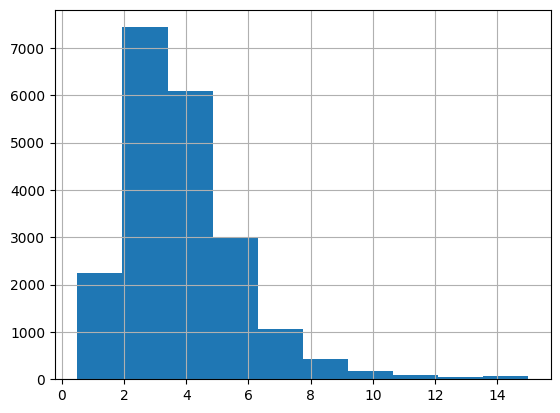

In [161]:
import matplotlib.pyplot as plt

df["median_income"].hist()

plt.show()

In [162]:
df["income_cat"] = pd.cut(df["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5])

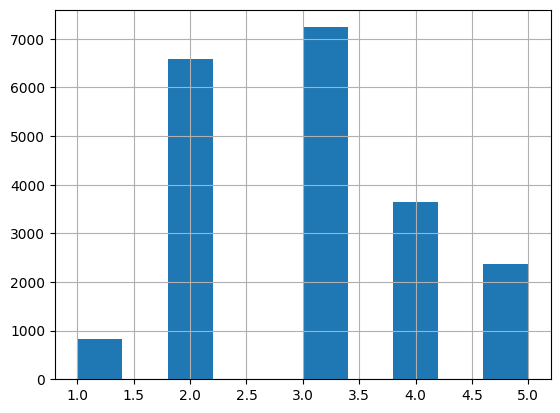

In [163]:
df["income_cat"].hist()

plt.show()

In [164]:
from sklearn.model_selection import train_test_split

In [165]:
str_train,str_test = train_test_split(df,test_size = 0.2, stratify = df["income_cat"] , random_state = 42)

In [166]:
str_test["income_cat"].value_counts(sort = False) 

income_cat
1     165
2    1316
3    1447
4     728
5     472
Name: count, dtype: int64

In [167]:
train_set, test_set = train_test_split(df, test_size=0.2,
                                       random_state=42)

In [168]:
ov = df["income_cat"].value_counts(sort=False)/len(df)
st = str_test["income_cat"].value_counts(sort = False)/len(str_test) 
sim = test_set["income_cat"].value_counts(sort = False)/len(test_set)

pd.DataFrame({"overall":ov,
    "stratified":st,
    "simple":sim,
     "e_st%":((st - ov)/ov )*100,
     "e_sim%":((sim - ov)/ov )*100               
                    })

,overall,stratified,simple,e_st%,e_sim%
income_cat,,,,,
1,0.039826,0.039971,0.042393,0.364964,6.447689
2,0.318847,0.318798,0.307413,-0.015195,-3.586081
3,0.350581,0.350533,0.345203,-0.013820,-1.533997
4,0.176308,0.176357,0.184109,0.027480,4.424292
5,0.114438,0.114341,0.120882,-0.084674,5.630821


In [169]:
for set_ in (str_train,str_test):
    set_.drop("income_cat", axis=1, inplace=True)

In [170]:
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)

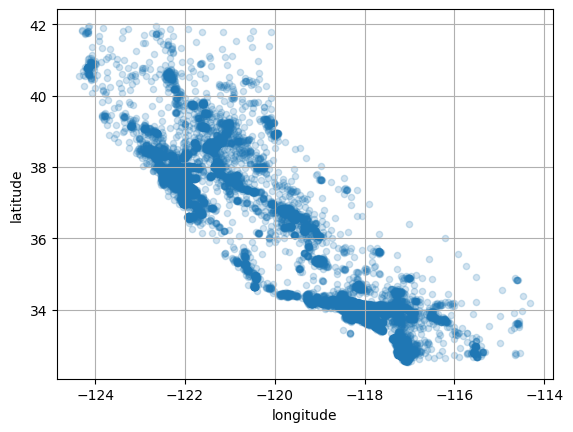

In [171]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True , alpha = 0.2)
plt.show()

In [172]:
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

In [173]:
housing_num = housing.select_dtypes([np.number])

In [174]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [175]:
imputer.statistics_

array([-118.49  ,   34.25  ,   29.    , 2129.    ,  437.    , 1169.    ,
        411.    ,    3.5246])

In [176]:
X = imputer.transform(housing_num)

In [177]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [178]:
housing_tr.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [179]:
X = imputer.transform(housing_num)

In [180]:
X

array([[-1.1722e+02,  3.2750e+01,  3.4000e+01, ...,  2.6540e+03,
         1.0720e+03,  4.5878e+00],
       [-1.1703e+02,  3.2690e+01,  1.0000e+01, ...,  6.9800e+02,
         1.6700e+02,  4.6648e+00],
       [-1.2227e+02,  3.7740e+01,  2.8000e+01, ...,  2.9740e+03,
         1.4840e+03,  3.6875e+00],
       ...,
       [-1.1933e+02,  3.6280e+01,  1.6000e+01, ...,  1.0770e+03,
         5.2000e+02,  2.1250e+00],
       [-1.1719e+02,  3.4080e+01,  2.2000e+01, ...,  1.5670e+03,
         4.9400e+02,  2.6536e+00],
       [-1.1886e+02,  3.4220e+01,  2.2000e+01, ...,  6.7300e+02,
         1.9500e+02,  6.2708e+00]])

In [181]:
housing_cat = test_set.select_dtypes(object)
housing_cat

,ocean_proximity
20046,INLAND
3024,<1H OCEAN
15663,NEAR OCEAN
20484,<1H OCEAN
9814,<1H OCEAN
...,...
15362,INLAND
16623,NEAR BAY
18086,INLAND
2144,<1H OCEAN


In [182]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

a = encoder.fit_transform(housing_cat)

In [183]:
print(a)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4128 stored elements and shape (4128, 4)>
  Coords	Values
  (0, 1)	1.0
  (1, 0)	1.0
  (2, 3)	1.0
  (3, 0)	1.0
  (4, 0)	1.0
  (5, 0)	1.0
  (6, 0)	1.0
  (7, 0)	1.0
  (8, 1)	1.0
  (9, 0)	1.0
  (10, 0)	1.0
  (11, 0)	1.0
  (12, 2)	1.0
  (13, 2)	1.0
  (14, 2)	1.0
  (15, 3)	1.0
  (16, 1)	1.0
  (17, 1)	1.0
  (18, 0)	1.0
  (19, 0)	1.0
  (20, 0)	1.0
  (21, 0)	1.0
  (22, 0)	1.0
  (23, 0)	1.0
  (24, 1)	1.0
  :	:
  (4103, 1)	1.0
  (4104, 0)	1.0
  (4105, 0)	1.0
  (4106, 0)	1.0
  (4107, 1)	1.0
  (4108, 0)	1.0
  (4109, 1)	1.0
  (4110, 0)	1.0
  (4111, 0)	1.0
  (4112, 0)	1.0
  (4113, 0)	1.0
  (4114, 1)	1.0
  (4115, 0)	1.0
  (4116, 1)	1.0
  (4117, 1)	1.0
  (4118, 1)	1.0
  (4119, 3)	1.0
  (4120, 1)	1.0
  (4121, 2)	1.0
  (4122, 1)	1.0
  (4123, 1)	1.0
  (4124, 2)	1.0
  (4125, 1)	1.0
  (4126, 0)	1.0
  (4127, 0)	1.0


In [184]:
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'NEAR BAY', 'NEAR OCEAN'], dtype=object)]

In [185]:
b = pd.get_dummies(housing_cat,dtype=int)

In [186]:
b

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
20046,0,1,0,0
3024,1,0,0,0
15663,0,0,0,1
20484,1,0,0,0
9814,1,0,0,0
...,...,...,...,...
15362,0,1,0,0
16623,0,0,1,0
18086,0,1,0,0
2144,1,0,0,0


In [187]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_minmax = scaler.fit_transform(housing_num)



In [188]:
housing_num_minmax

array([[ 0.42031873, -0.95536663,  0.29411765, ..., -0.85139718,
        -0.6477553 , -0.4361595 ],
       [ 0.45816733, -0.96811902, -0.64705882, ..., -0.96104151,
        -0.94540372, -0.42553896],
       [-0.58565737,  0.10520723,  0.05882353, ..., -0.83345946,
        -0.51225127, -0.5603371 ],
       ...,
       [ 0.        , -0.20510096, -0.41176471, ..., -0.93979652,
        -0.82930439, -0.77585137],
       [ 0.42629482, -0.67268863, -0.17647059, ..., -0.91232938,
        -0.83785562, -0.70294203],
       [ 0.0936255 , -0.64293305, -0.17647059, ..., -0.96244289,
        -0.9361947 , -0.20402477]])

In [189]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
housing_num_stdSca = scaler2.fit_transform(housing_num)

In [190]:
housing_num_stdSca = pd.DataFrame(housing_num_stdSca, columns=housing_num.columns,
                          index=housing_num.index)

housing_num_stdSca

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14196,1.172993,-1.350415,0.428537,1.570557,1.367982,1.081011,1.507507,0.379698
8267,1.268028,-1.378536,-1.473509,-0.809439,-0.898930,-0.643842,-0.878707,0.420068
17445,-1.352939,0.988349,-0.046974,1.994289,2.427309,1.363196,2.593828,-0.092320
14265,-1.127856,0.758691,-0.284730,0.646558,0.227353,0.661262,0.394820,0.682999
2271,1.793222,-1.083261,-1.632013,-1.117906,-1.178707,-1.203802,-1.255755,-1.255560
...,...,...,...,...,...,...,...,...
11284,-1.402957,1.082087,1.617317,-0.777706,-0.741107,-0.731143,-0.804879,-1.335305
11964,0.592779,-0.816108,0.507789,-0.400173,-0.499590,-0.613860,-0.496385,1.421304
5390,0.117604,0.304062,-0.997998,-0.005374,-0.028512,-0.309630,0.052048,-0.911522
860,1.187999,-0.727057,-0.522486,-0.078641,0.038443,0.122465,-0.016506,-0.634382


In [191]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

In [192]:
age_simil_35

array([[9.04837418e-01],
       [7.18778174e-28],
       [7.44658307e-03],
       ...,
       [2.09879105e-16],
       [4.57533877e-08],
       [4.57533877e-08]])

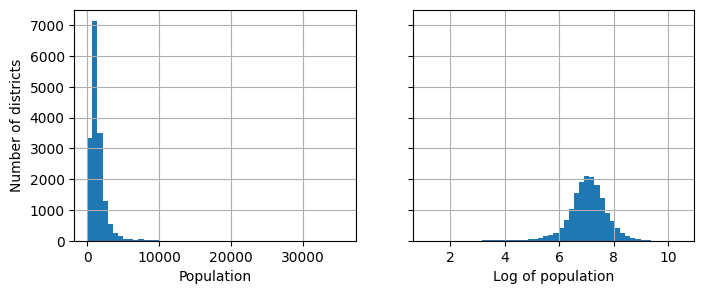

In [193]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

In [194]:
from sklearn.linear_model import LinearRegression
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [195]:
predictions

array([[236054.10114638],
       [239237.69758773],
       [198830.83002753],
       [259972.41986486],
       [107097.77256737]])

In [196]:
scaled_predictions

array([[ 0.26085752],
       [ 0.28859244],
       [-0.06342485],
       [ 0.46922957],
       [-0.86258658]])

In [197]:
from sklearn.compose import TransformedTargetRegressor
model = TransformedTargetRegressor(LinearRegression(),transformer=StandardScaler())

model.fit(housing[["median_income"]],housing_labels)

predictions = model.predict(some_new_data)


In [198]:
predictions

array([236054.10114638, 239237.69758773, 198830.83002753, 259972.41986486,
       107097.77256737])

In [199]:

from sklearn.preprocessing import FunctionTransformer

transformer = FunctionTransformer(np.log , inverse_func= np.exp)

In [200]:
log_pop = transformer.transform(housing[["population"]])
type(log_pop)

pandas.core.frame.DataFrame

In [201]:

ab = pd.concat([log_pop, housing["population"]], axis=1)
ab.columns = ["log","normal"]
ab


,log,normal
14196,7.883823,2654.0
8267,6.548219,698.0
17445,7.997663,2974.0
14265,7.686162,2178.0
2271,4.143135,63.0
...,...,...
11284,6.395262,599.0
11964,6.595781,732.0
5390,6.981935,1077.0
860,7.356918,1567.0


array([[<Axes: title={'center': 'log'}>,
        <Axes: title={'center': 'normal'}>]], dtype=object)

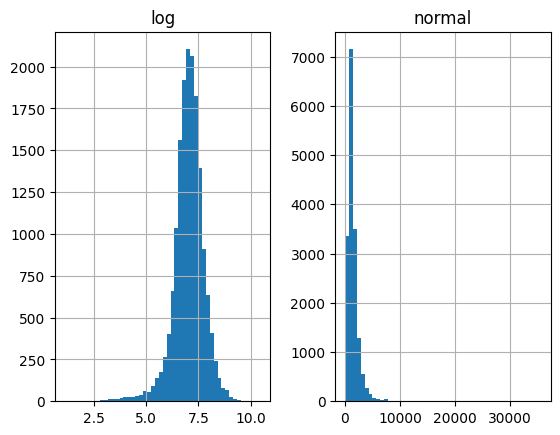

In [202]:
ab.hist(bins = 50)

In [203]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("standerdize",StandardScaler())
])

In [204]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)

In [205]:
type(housing_num)

pandas.core.frame.DataFrame

In [206]:
num_pipeline.get_feature_names_out()

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [207]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
                    SimpleImputer(strategy="most_frequent"),
                    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",cat_pipeline,cat_attribs)]
)

In [208]:
from sklearn.compose import make_column_selector , make_column_transformer

preprocessing = make_column_transformer((num_pipeline , make_column_selector(dtype_include=np.number)),
                                         (cat_pipeline, make_column_selector(dtype_include=object)))

In [209]:
housing_prepared = preprocessing.fit_transform(housing)

In [210]:
pd.DataFrame(housing_prepared , columns=preprocessing.get_feature_names_out() , index=housing.index)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
14196,1.172993,-1.350415,0.428537,1.570557,1.376799,1.081011,1.507507,0.379698,0.0,0.0,0.0,0.0,1.0
8267,1.268028,-1.378536,-1.473509,-0.809439,-0.900718,-0.643842,-0.878707,0.420068,0.0,0.0,0.0,0.0,1.0
17445,-1.352939,0.988349,-0.046974,1.994289,2.441082,1.363196,2.593828,-0.092320,0.0,0.0,0.0,1.0,0.0
14265,-1.127856,0.758691,-0.284730,0.646558,0.230833,0.661262,0.394820,0.682999,1.0,0.0,0.0,0.0,0.0
2271,1.793222,-1.083261,-1.632013,-1.117906,-1.181804,-1.203802,-1.255755,-1.255560,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-1.402957,1.082087,1.617317,-0.777706,-0.742156,-0.731143,-0.804879,-1.335305,0.0,0.0,0.0,1.0,0.0
11964,0.592779,-0.816108,0.507789,-0.400173,-0.499510,-0.613860,-0.496385,1.421304,1.0,0.0,0.0,0.0,0.0
5390,0.117604,0.304062,-0.997998,-0.005374,-0.026228,-0.309630,0.052048,-0.911522,0.0,1.0,0.0,0.0,0.0
860,1.187999,-0.727057,-0.522486,-0.078641,0.041040,0.122465,-0.016506,-0.634382,0.0,1.0,0.0,0.0,0.0


In [211]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [212]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [213]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing , LinearRegression())
lin_reg.fit(housing , housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

In [214]:
housing_prediction = lin_reg.predict(housing)

In [215]:
housing_prediction
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels,housing_prediction)

In [216]:
lin_rmse

69139.49349006142

In [217]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))

In [218]:
tree_reg.fit(housing , housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [219]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

In [220]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg , housing , housing_labels , cv =10 , scoring= "neg_root_mean_squared_error")

In [221]:
print(pd.Series(tree_rmses).describe())

print(pd.Series(tree_rmses))

count       10.000000
mean     65827.196394
std       2175.754402
min      63020.271955
25%      63975.187870
50%      65968.085410
75%      66497.079214
max      69928.842381
dtype: float64
0    63634.603298
1    64996.941589
2    66334.826821
3    66551.163344
4    68313.994327
5    63555.149404
6    69928.842381
7    66313.176049
8    63020.271955
9    65622.994772
dtype: float64


In [222]:
# from sklearn.ensemble import RandomForestRegressor # takes 1 min to run and uncomment before running
# forest_reg = make_pipeline(preprocessing , RandomForestRegressor(random_state=42))
# forest_rmses = -cross_val_score(forest_reg , housing , housing_labels , cv = 4 , scoring = "neg_root_mean_squared_error")

In [223]:
pd.Series(forest_rmses).describe()

count        4.000000
mean     47596.127293
std        393.183469
min      47169.735457
25%      47390.887157
50%      47553.098531
75%      47758.338667
max      48108.576655
dtype: float64

In [227]:
#fine tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [230]:
full_pipeline = Pipeline([
    ("preprocessing" , preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
    'random_forest__max_features': [4, 6, 8]
    },
    {'preprocessing__geo__n_clusters': [10, 15],
    'random_forest__max_features': [6, 8, 10]
    }]

In [ ]:
# grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, # takes 2m 30 sec to run uncomment before running
# scoring='neg_root_mean_squared_error')
# grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity

In [232]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [233]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)


In [234]:
cv_res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,2.755701,0.009269,0.090111,0.000155,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43537.836254,-44544.890584,-44231.982179,-44104.903006,420.833651,1
13,3.553918,0.040438,0.089354,0.000652,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44189.905095,-44510.922084,-44354.416489,-44351.747889,131.068221,2
14,4.328780,0.014951,0.091744,0.001233,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44434.527821,-44922.867265,-44894.425593,-44750.606893,223.803064,3
6,2.155478,0.118387,0.096998,0.004169,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-44956.626012,-45529.837002,-45380.798623,-45289.087212,242.831831,4
7,2.871049,0.098661,0.107586,0.017736,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45010.309498,-45352.093369,-45541.607480,-45301.336783,219.850797,5
9,2.717281,0.007741,0.092252,0.001863,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45010.309498,-45352.093369,-45541.607480,-45301.336783,219.850797,5
8,3.485631,0.023849,0.090347,0.000618,10,8,"{'preprocessing__geo__n_clusters': 10, 'random...",-45207.057618,-45610.705142,-45826.023141,-45547.928633,256.560905,7
10,3.587768,0.098336,0.091980,0.002512,10,8,"{'preprocessing__geo__n_clusters': 10, 'random...",-45207.057618,-45610.705142,-45826.023141,-45547.928633,256.560905,7
4,3.005904,0.125199,0.104252,0.007658,8,6,"{'preprocessing__geo__n_clusters': 8, 'random_...",-45082.293612,-46239.058755,-45611.795201,-45644.382522,472.809228,9
3,2.137731,0.193323,0.099636,0.010371,8,4,"{'preprocessing__geo__n_clusters': 8, 'random_...",-45094.585802,-46585.561471,-45786.294972,-45822.147415,609.215977,10


In [235]:
[...]

[Ellipsis]

In [236]:
cv_res.head() 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,2.755701,0.009269,0.090111,0.000155,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43537.836254,-44544.890584,-44231.982179,-44104.903006,420.833651,1
13,3.553918,0.040438,0.089354,0.000652,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44189.905095,-44510.922084,-44354.416489,-44351.747889,131.068221,2
14,4.328780,0.014951,0.091744,0.001233,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44434.527821,-44922.867265,-44894.425593,-44750.606893,223.803064,3
6,2.155478,0.118387,0.096998,0.004169,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-44956.626012,-45529.837002,-45380.798623,-45289.087212,242.831831,4
7,2.871049,0.098661,0.107586,0.017736,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45010.309498,-45352.093369,-45541.607480,-45301.336783,219.850797,5


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

params_dist = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    'random_forest__max_features': randint(low=2, high=20)
}

In [239]:
rnd_search = RandomizedSearchCV(full_pipeline, param_distributions=params_dist, n_iter=10, cv=3,
scoring='neg_root_mean_squared_error', random_state=42)

In [ ]:
# rnd_search.fit(housing, housing_labels) # takes 2 min to run uncoment bofre executing

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....t 0x135c617f0>, 'random_forest__max_features': <scipy.stats....t 0x135cd2ed0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [243]:
rn_res = pd.DataFrame(rnd_search.cv_results_)
rn_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

In [244]:
rn_res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,4.148983,0.038033,0.090491,0.000450,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41474.900157,-42129.928484,-42461.636026,-42022.154889,409.978276,1
8,3.325892,0.013141,0.092138,0.000536,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-41645.185991,-42754.648175,-43042.241623,-42480.691930,602.345487,2
5,2.135514,0.015824,0.091174,0.000812,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-41896.152577,-42677.858938,-43266.966295,-42613.659270,561.470546,3
0,7.053962,0.068239,0.091597,0.001636,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42414.542016,-42807.683599,-43350.661372,-42857.628996,383.797489,4
2,3.654721,0.006488,0.090423,0.001222,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42622.334352,-43587.440296,-43342.464688,-43184.079778,409.610958,5
7,5.763972,0.046500,0.091403,0.000731,26,13,"{'preprocessing__geo__n_clusters': 26, 'random...",-43447.015238,-43819.199957,-43703.555533,-43656.590242,155.530640,6
6,1.654035,0.007192,0.089355,0.000557,24,3,"{'preprocessing__geo__n_clusters': 24, 'random...",-43021.161515,-44082.757727,-43972.614534,-43692.177925,476.606160,7
3,5.285299,0.026654,0.091135,0.000795,21,12,"{'preprocessing__geo__n_clusters': 21, 'random...",-43838.640230,-44336.190781,-44208.280929,-44127.703980,210.963854,8
4,2.368066,0.023328,0.089827,0.000285,13,5,"{'preprocessing__geo__n_clusters': 13, 'random...",-44244.999684,-44797.159656,-44502.311255,-44514.823532,225.591927,9
9,1.149763,0.005613,0.090276,0.000517,4,2,"{'preprocessing__geo__n_clusters': 4, 'random_...",-51921.382427,-50740.730339,-51344.044388,-51335.385718,482.038081,10


In [245]:
final_model = rnd_search.best_estimator_

In [246]:
feature_importances = final_model["random_forest"].feature_importances_

In [247]:
sorted(zip(feature_importances,final_model["preprocessing"].get_feature_names_out()),
       reverse=True)

[(np.float64(0.18549025228502308), 'log__median_income'),
 (np.float64(0.07848300973934626), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.07316164062565585), 'bedrooms__ratio'),
 (np.float64(0.055819073661098624), 'rooms_per_house__ratio'),
 (np.float64(0.046925479432196916), 'people_per_house__ratio'),
 (np.float64(0.02848928863844994), 'geo__Cluster 23 similarity'),
 (np.float64(0.025496108701767824), 'geo__Cluster 2 similarity'),
 (np.float64(0.024117174626570224), 'geo__Cluster 34 similarity'),
 (np.float64(0.021213626996959865), 'geo__Cluster 18 similarity'),
 (np.float64(0.02061997287178964), 'geo__Cluster 21 similarity'),
 (np.float64(0.01859383539994067), 'geo__Cluster 7 similarity'),
 (np.float64(0.01719294875688189), 'geo__Cluster 30 similarity'),
 (np.float64(0.01660208710540888), 'geo__Cluster 6 similarity'),
 (np.float64(0.014441126716306549), 'geo__Cluster 25 similarity'),
 (np.float64(0.013690353127368831), 'geo__Cluster 41 similarity'),
 (np.float64(0.0136768793019554